In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import time
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt
import pandas as pd

# NOE

u shape: (35000,)
th shape: (35000,)


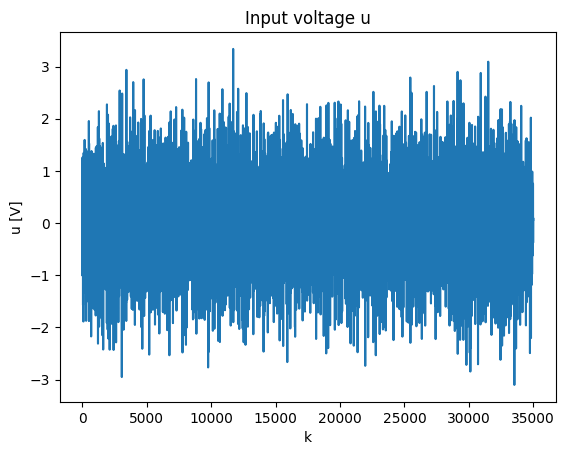

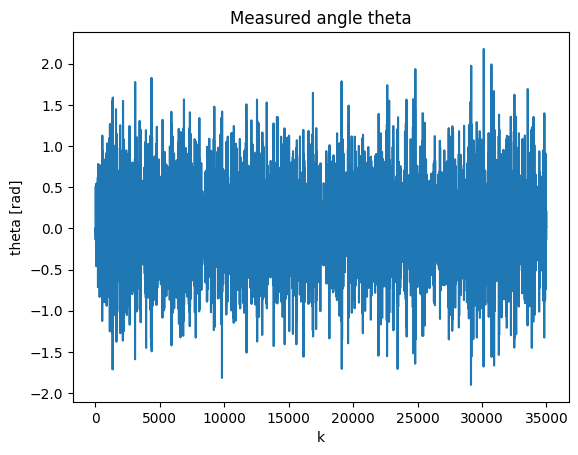

In [16]:
out = np.load("training-val-test-data.npz")

th = out["th"]   # measured disk angle
u = out["u"]     # applied input voltage

print("u shape:", u.shape)
print("th shape:", th.shape)

plt.figure()
plt.plot(u)
plt.title("Input voltage u")
plt.xlabel("k")
plt.ylabel("u [V]")
plt.show()

plt.figure()
plt.plot(th)
plt.title("Measured angle theta")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.show()

## Split into training - validation - test

 A block split was used instead of a random split because the data are time-series samples and neighboring points are correlated. This prevents data leakage between the training and validation/test sets.

In [17]:
N = len(u)

N_train = int(0.7 * N)
N_val = int(0.15 * N)

u_train = u[:N_train]
th_train = th[:N_train]

u_val = u[N_train:N_train + N_val]
th_val = th[N_train:N_train + N_val]

u_test = u[N_train + N_val:]
th_test = th[N_train + N_val:]

print(len(u_train), len(u_val), len(u_test))

24500 5250 5250


## Normalization 

The input voltage and measured angle were normalized to zero mean and unit variance before training. The normalization constants were computed only from the training set and then applied to the validation and test sets. This avoids data leakage and improves the conditioning of the neural network training problem.

In [18]:
u_mean = u_train.mean()
u_std = u_train.std()

th_mean = th_train.mean()
th_std = th_train.std()

u_train_n = (u_train - u_mean) / u_std
u_val_n = (u_val - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

th_train_n = (th_train - th_mean) / th_std
th_val_n = (th_val - th_mean) / th_std
th_test_n = (th_test - th_mean) / th_std

print("u mean/std:", u_mean, u_std)
print("theta mean/std:", th_mean, th_std)

u mean/std: -2.687187240524085e-05 0.8410479397424789
theta mean/std: 0.03394048474666838 0.46785269160434234


## Construction of simulation windows

For NOE training, the time series was converted into overlapping input-output windows of length `nf = 100`. Each window contains a sequence of past input voltages and the corresponding measured output angles. These windows are used to train the model on short free-run simulation rollouts instead of only one-step-ahead samples.

In [19]:
def make_OE_data(udata, ydata, nf=100):
    U = [] 
    Y = [] 
    for k in range(nf, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])
    return np.array(U), np.array(Y)

## Choice of rollout horizon

A rollout horizon of `nf = 100` samples was used for training. This means that the NOE model is optimized to simulate output trajectories over short windows of 100 samples. The resulting training set contains 24,401 overlapping windows, while the validation set contains 5,151 windows.

In [20]:
nfuture = 100

U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

print("U_train:", U_train.shape)
print("Y_train:", Y_train.shape)
print("U_val:", U_val.shape)
print("Y_val:", Y_val.shape)

U_train: (24401, 100)
Y_train: (24401, 100)
U_val: (5151, 100)
Y_val: (5151, 100)


## NOE neural network structure

A nonlinear output-error (NOE) model was implemented using a feedforward neural network as the nonlinear mapping. At each time step, the network receives delayed input voltages and delayed model outputs as regressors

In [21]:
class NOENet(nn.Module):
    def __init__(self, na=5, nb=5, hidden_size=64):
        super().__init__()

        self.na = na
        self.nb = nb
        self.n0 = max(na, nb)

        input_size = na + nb

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, U_seq, Y_seq):
        """
        U_seq: shape (batch, sequence_length)
        Y_seq: shape (batch, sequence_length)

        We use the first n0 true outputs only for initialization.
        After that, the model recursively feeds back its own predictions.
        """

        batch_size, seq_len = U_seq.shape

        # first n0 samples are used as initial conditions
        y_generated = []
        for i in range(self.n0):
            y_generated.append(Y_seq[:, i])

        # recursive simulation
        for t in range(self.n0, seq_len):
            u_lags = U_seq[:, t-self.nb:t]
            y_lags = torch.stack(y_generated[t-self.na:t], dim=1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = self.net(x).squeeze(1)
            y_generated.append(y_next)

        Y_hat = torch.stack(y_generated, dim=1)

        return Y_hat

In [22]:
class NOENetResidual(nn.Module):
    def __init__(self, na=5, nb=5, hidden_size=32):
        super().__init__()

        self.na = na
        self.nb = nb
        self.n0 = max(na, nb)

        input_size = na + nb

        self.linear = nn.Linear(input_size, 1)

        self.nonlinear = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def predict_from_lags(self, x):
        return self.linear(x).squeeze(1) + self.nonlinear(x).squeeze(1)

    def forward(self, U_seq, Y_seq):
        batch_size, seq_len = U_seq.shape

        y_generated = []
        for i in range(self.n0):
            y_generated.append(Y_seq[:, i])

        for t in range(self.n0, seq_len):
            u_lags = U_seq[:, t-self.nb:t]
            y_lags = torch.stack(y_generated[t-self.na:t], dim=1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = self.predict_from_lags(x)
            y_generated.append(y_next)

        return torch.stack(y_generated, dim=1)

## Mini-batch training data loader

The training windows were wrapped in a PyTorch `TensorDataset` and loaded using mini-batches of size 256. Shuffling was applied at the window level, not inside the sequences, so the temporal order within each rollout window is preserved while still enabling stochastic mini-batch optimization.

In [23]:
from torch.utils.data import TensorDataset, DataLoader

U_train_t = torch.tensor(U_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

U_val_t = torch.tensor(U_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

train_dataset = TensorDataset(U_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(U_train_t.shape, Y_train_t.shape)

torch.Size([24401, 100]) torch.Size([24401, 100])


## NOE training procedure

The NOE model was trained by minimizing the mean squared simulation error over the rollout windows. The loss was computed only after the initialization period, since the first n0 samples are used as measured initial conditions and are not generated by the model. The Adam optimizer was used for parameter updates. Gradient clipping was applied to improve numerical stability during recursive simulation training. The model state with the lowest validation simulation loss was stored and restored after training.

In [33]:
def train_noe(model, train_loader, U_val_t, Y_val_t, epochs=100, lr=1e-3, weight_decay=1e-6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=25,
        min_lr=1e-5
    )

    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for U_batch, Y_batch in train_loader:
            optimizer.zero_grad()

            Y_hat = model(U_batch, Y_batch)

            loss = loss_fn(Y_hat[:, model.n0:], Y_batch[:, model.n0:])

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            Y_val_hat = model(U_val_t, Y_val_t)
            val_loss = loss_fn(Y_val_hat[:, model.n0:], Y_val_t[:, model.n0:]).item()

        # Put it here
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:4d} | "
                f"train sim loss = {train_loss:.6f} | "
                f"val sim loss = {val_loss:.6f} | "
                f"lr = {current_lr:.2e}"
            )

    model.load_state_dict(best_state)

    return train_losses, val_losses

### Full free-run NOE simulation

A full free-run simulation function was implemented to evaluate the NOE model on an entire validation sequence. The first n_0=maxn_a,n_b measured output samples were used only for initialization. After that, the model recursively predicted the output and fed each prediction back as a delayed output for the next time step. This corresponds to the simulation behavior of a nonlinear output-error model.

In [25]:
def simulate_noe_full(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_generated = []

    for i in range(n0):
        y_generated.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)

            # Safety check while debugging
            assert u_lags.shape[1] == nb, f"u_lags has {u_lags.shape[1]} values, expected {nb}"
            assert y_lags.shape[1] == na, f"y_lags has {y_lags.shape[1]} values, expected {na}"

            x = torch.cat([u_lags, y_lags], dim=1)

            assert x.shape[1] == na + nb, f"x has {x.shape[1]} values, expected {na + nb}"

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_generated.append(y_next)

    y_hat_n = torch.stack(y_generated).numpy()

    y_hat = y_hat_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_hat, y_true

## Full validation simulation metric function

In [26]:
def evaluate_noe_full(model, u_val_n, th_val_n, th_mean, th_std):
    th_val_sim, th_val_true = simulate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
    rms_deg = rms / (2*np.pi) * 360
    nrms = rms / np.std(th_val_true[skip:])

    return rms, rms_deg, nrms * 100, th_val_sim, th_val_true

In [30]:
def one_step_prediction_noe(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_pred = []

    for i in range(n0):
        y_pred.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = y_t[t-na:t].reshape(1, -1)

            x = torch.cat([u_lags, y_lags], dim=1)

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_pred.append(y_next)

    y_pred_n = torch.stack(y_pred).numpy()

    y_pred_denorm = y_pred_n * th_std + th_mean
    y_true_denorm = y_seq * th_std + th_mean

    return y_pred_denorm, y_true_denorm

## NOE hyperparameter tuning summary and final model training

In [ ]:
noe_configs = [
{"nfuture": 70, "na": 5, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
{"nfuture": 80, "na": 5, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
]
noe_results = []

best_noe_rmse = np.inf
best_noe_model = None
best_noe_config = None
best_noe_losses = None
best_noe_sim = None
best_noe_true = None

for cfg in noe_configs:
    print("\n====================================")
    print("Training NOE config:", cfg)
    print("====================================")

    nfuture = cfg["nfuture"]

    U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
    U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

    U_train_t = torch.tensor(U_train, dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    U_val_t = torch.tensor(U_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

    train_dataset = TensorDataset(U_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses_tmp, val_losses_tmp = train_noe(
        model,
        train_loader,
        U_val_t,
        Y_val_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    rms, rms_deg, nrms_percent, th_val_sim_tmp, th_val_true_tmp = evaluate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    # One-step prediction metric
    th_val_pred_tmp, th_val_true_pred_tmp = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(
        np.mean((th_val_pred_tmp[skip:] - th_val_true_pred_tmp[skip:])**2)
    )
    pred_rms_deg = pred_rms / (2 * np.pi) * 360
    pred_nrms_percent = pred_rms / np.std(th_val_true_pred_tmp[skip:]) * 100

    combined_score = pred_rms / 0.00665 + rms / 0.0271

    result = {
        "nfuture": cfg["nfuture"],
        "na": cfg["na"],
        "nb": cfg["nb"],
        "hidden_size": cfg["hidden_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "epochs": cfg["epochs"],

        "prediction_rmse_rad": pred_rms,
        "prediction_rmse_deg": pred_rms_deg,
        "prediction_nrms_percent": pred_nrms_percent,

        "simulation_rmse_rad": rms,
        "simulation_rmse_deg": rms_deg,
        "simulation_nrms_percent": nrms_percent,

        "combined_score": combined_score,

        "best_window_val_loss": np.min(val_losses_tmp),
        "best_epoch": int(np.argmin(val_losses_tmp))
    }

    noe_results.append(result)

    print("One-step prediction RMSE:", pred_rms, "rad")
    print("One-step prediction NRMS:", pred_nrms_percent, "%")
    print("Full validation simulation RMSE:", rms, "rad")
    print("Full validation simulation NRMS:", nrms_percent, "%")
    print("Combined score:", combined_score)


Training NOE config: {'nfuture': 70, 'na': 5, 'nb': 3, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 300}
Epoch    0 | train sim loss = 0.785148 | val sim loss = 0.759408 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.089293 | val sim loss = 0.130049 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.019662 | val sim loss = 0.051553 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.011126 | val sim loss = 0.037743 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.008492 | val sim loss = 0.029761 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.007083 | val sim loss = 0.024727 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.006869 | val sim loss = 0.021684 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.006185 | val sim loss = 0.022955 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.004865 | val sim loss = 0.017469 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.004846 | val sim loss = 0.018535 | lr = 3.00e-04
Epoch  100 | train sim loss = 0.005479 | val sim loss = 0.01836

In [ ]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:
base_cfg = {
    "nfuture": 75,
    "na": 5,
    "nb": 3,
    "hidden_size": 32,
    "lr": 3e-4,
    "weight_decay": 1e-6,
    "epochs": 300
}

seeds = [0, 1, 2, 3, 4]

seed_results = []

for seed in seeds:
    print("\n====================================")
    print("Training seed:", seed)
    print("Config:", base_cfg)
    print("====================================")

    set_seed(seed)

    nfuture = base_cfg["nfuture"]

    U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
    U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

    U_train_t = torch.tensor(U_train, dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    U_val_t = torch.tensor(U_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

    train_dataset = TensorDataset(U_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    model = NOENet(
        na=base_cfg["na"],
        nb=base_cfg["nb"],
        hidden_size=base_cfg["hidden_size"]
    )

    train_losses_tmp, val_losses_tmp = train_noe(
        model,
        train_loader,
        U_val_t,
        Y_val_t,
        epochs=base_cfg["epochs"],
        lr=base_cfg["lr"],
        weight_decay=base_cfg["weight_decay"]
    )

    sim_rms, sim_rms_deg, sim_nrms_percent, th_val_sim_tmp, th_val_true_tmp = evaluate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    th_val_pred_tmp, th_val_true_pred_tmp = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(
        np.mean((th_val_pred_tmp[skip:] - th_val_true_pred_tmp[skip:])**2)
    )

    pred_nrms_percent = pred_rms / np.std(th_val_true_pred_tmp[skip:]) * 100

    combined_score = pred_rms / 0.00665 + sim_rms / 0.0271

    result = {
        "seed": seed,
        **base_cfg,
        "prediction_rmse_rad": pred_rms,
        "prediction_nrms_percent": pred_nrms_percent,
        "simulation_rmse_rad": sim_rms,
        "simulation_nrms_percent": sim_nrms_percent,
        "combined_score": combined_score,
        "best_window_val_loss": np.min(val_losses_tmp),
        "best_epoch": int(np.argmin(val_losses_tmp))
    }

    seed_results.append(result)

    print("Prediction RMSE:", pred_rms)
    print("Simulation RMSE:", sim_rms)
    print("Combined score:", combined_score)

seed_results_df = pd.DataFrame(seed_results)
seed_results_df.sort_values("combined_score")

In [34]:
noe_configs = [
    {"nfuture": 40, "na": 5, "nb": 2, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
    {"nfuture": 50, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
    {"nfuture": 60, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},

    {"nfuture": 40, "na": 6, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
    {"nfuture": 50, "na": 6, "nb": 2, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
    {"nfuture": 60, "na": 7, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},

    {"nfuture": 40, "na": 5, "nb": 5, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
    {"nfuture": 50, "na": 5, "nb": 5, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 300},
]
noe_results = []

best_noe_rmse = np.inf
best_noe_model = None
best_noe_config = None
best_noe_losses = None
best_noe_sim = None
best_noe_true = None

for cfg in noe_configs:
    print("\n====================================")
    print("Training NOE config:", cfg)
    print("====================================")

    nfuture = cfg["nfuture"]

    if nfuture <= max(cfg["na"], cfg["nb"]):
        print("Skipping config: nfuture must be larger than max(na, nb)")
        continue

    # Rebuild training windows for this nfuture
    U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
    U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

    U_train_t = torch.tensor(U_train, dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    U_val_t = torch.tensor(U_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

    train_dataset = TensorDataset(U_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    print("U_train:", U_train.shape)
    print("Y_train:", Y_train.shape)
    print("U_val:", U_val.shape)
    print("Y_val:", Y_val.shape)

    model = NOENetResidual(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses_tmp, val_losses_tmp = train_noe(
        model,
        train_loader,
        U_val_t,
        Y_val_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    # Full free-run simulation metric
    sim_rms, sim_rms_deg, sim_nrms_percent, th_val_sim_tmp, th_val_true_tmp = evaluate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    # One-step prediction metric
    th_val_pred_tmp, th_val_true_pred_tmp = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(
        np.mean((th_val_pred_tmp[skip:] - th_val_true_pred_tmp[skip:])**2)
    )
    pred_rms_deg = pred_rms / (2 * np.pi) * 360
    pred_nrms_percent = pred_rms / np.std(th_val_true_pred_tmp[skip:]) * 100

    combined_score = pred_rms / 0.00665 + sim_rms / 0.0271

    result = {
        "nfuture": cfg["nfuture"],
        "na": cfg["na"],
        "nb": cfg["nb"],
        "hidden_size": cfg["hidden_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "epochs": cfg["epochs"],

        "prediction_rmse_rad": pred_rms,
        "prediction_rmse_deg": pred_rms_deg,
        "prediction_nrms_percent": pred_nrms_percent,

        "simulation_rmse_rad": sim_rms,
        "simulation_rmse_deg": sim_rms_deg,
        "simulation_nrms_percent": sim_nrms_percent,

        "combined_score": combined_score,


        "best_window_val_loss": np.min(val_losses_tmp),
        "best_epoch": int(np.argmin(val_losses_tmp))
    }

    noe_results.append(result)

    print("One-step prediction RMSE:", pred_rms, "rad")
    print("One-step prediction NRMS:", pred_nrms_percent, "%")
    print("Full validation simulation RMSE:", sim_rms, "rad")
    print("Full validation simulation NRMS:", sim_nrms_percent, "%")
    print("Combined score:", combined_score)

    # Keep best model by full simulation RMSE.
    # You can change this criterion later if prediction is more important.
    if sim_rms < best_noe_rmse:
        best_noe_rmse = sim_rms
        best_noe_model = copy.deepcopy(model)
        best_noe_config = copy.deepcopy(cfg)
        best_noe_losses = (train_losses_tmp, val_losses_tmp)
        best_noe_sim = th_val_sim_tmp
        best_noe_true = th_val_true_tmp

noe_results_df = pd.DataFrame(noe_results)
noe_results_df.sort_values(["prediction_rmse_rad", "simulation_rmse_rad"])


Training NOE config: {'nfuture': 40, 'na': 5, 'nb': 2, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 300}
U_train: (24461, 40)
Y_train: (24461, 40)
U_val: (5211, 40)
Y_val: (5211, 40)
Epoch    0 | train sim loss = 0.990977 | val sim loss = 1.002905 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.085430 | val sim loss = 0.126379 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.033196 | val sim loss = 0.057141 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.014300 | val sim loss = 0.029238 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.011030 | val sim loss = 0.021298 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.009352 | val sim loss = 0.019801 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.008315 | val sim loss = 0.016482 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.007527 | val sim loss = 0.015694 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.007094 | val sim loss = 0.013960 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.006204 | val sim loss = 0.012410 |

KeyboardInterrupt: 

In [25]:
print("Best NOE configuration:")
print(best_noe_config)

print("\nBest NOE full validation simulation RMSE:", best_noe_rmse, "rad")

best_row = noe_results_df.loc[noe_results_df["rmse_rad"].idxmin()]
best_row

Best NOE configuration:
{'nfuture': 50, 'na': 5, 'nb': 2, 'hidden_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 300}

Best NOE full validation simulation RMSE: 0.9883009562657256 rad


KeyError: 'rmse_rad'

## One prediction test

In [42]:
final_noe_model.eval()  # change this to model_noe_250 if needed

th_val_pred, th_val_true_pred = one_step_prediction_noe(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
pred_rms_deg = pred_rms / (2*np.pi) * 360
pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

print("Validation one-step prediction RMS:", pred_rms, "rad")
print("Validation one-step prediction RMS:", pred_rms_deg, "deg")
print("Validation one-step prediction NRMS:", pred_nrms * 100, "%")

Validation one-step prediction RMS: 0.005317990239418509 rad
Validation one-step prediction RMS: 0.3046983962104468 deg
Validation one-step prediction NRMS: 1.0804475745192827 %


In [43]:
noe_results_df_sorted = noe_results_df.sort_values("rmse_rad")
noe_results_df_sorted

,na,nb,hidden_size,lr,weight_decay,epochs,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,5,5,20,0.001,0.000001,150,0.077579,4.444977,15.7617,0.016603,139


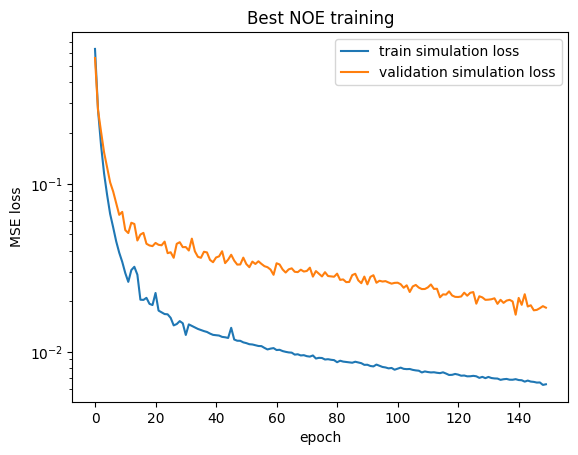

Best epoch based on validation-window loss: 139
Best validation-window loss: 0.0166025310754776


In [44]:
train_losses, val_losses = best_noe_losses

plt.figure()
plt.plot(train_losses, label="train simulation loss")
plt.plot(val_losses, label="validation simulation loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Best NOE training")
plt.legend()
plt.show()

print("Best epoch based on validation-window loss:", int(np.argmin(val_losses)))
print("Best validation-window loss:", np.min(val_losses))

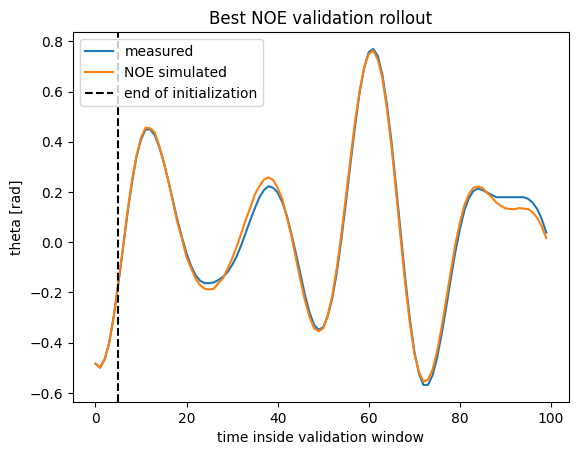

Validation rollout RMS: 0.024119979 rad
Validation rollout RMS: 1.3819729855013074 deg
Validation rollout NRMS: 8.149301260709763 %


In [45]:
final_noe_model = best_noe_model
final_noe_model.eval()

with torch.no_grad():
    Y_val_hat = final_noe_model(U_val_t[:1], Y_val_t[:1]).numpy()

Y_true = Y_val_t[:1].numpy()

# denormalize
Y_hat_denorm = Y_val_hat[0] * th_std + th_mean
Y_true_denorm = Y_true[0] * th_std + th_mean

plt.figure()
plt.plot(Y_true_denorm, label="measured")
plt.plot(Y_hat_denorm, label="NOE simulated")
plt.axvline(final_noe_model.n0, color="black", linestyle="--", label="end of initialization")
plt.xlabel("time inside validation window")
plt.ylabel("theta [rad]")
plt.title("Best NOE validation rollout")
plt.legend()
plt.show()

rms_window = np.sqrt(
    np.mean((Y_hat_denorm[final_noe_model.n0:] - Y_true_denorm[final_noe_model.n0:])**2)
)
rms_window_deg = rms_window / (2*np.pi) * 360
nrms_window = rms_window / np.std(Y_true_denorm[final_noe_model.n0:])

print("Validation rollout RMS:", rms_window, "rad")
print("Validation rollout RMS:", rms_window_deg, "deg")
print("Validation rollout NRMS:", nrms_window * 100, "%")

Full validation simulation RMS: 0.07757948611626973 rad
Full validation simulation RMS: 4.444977131256022 deg
Full validation simulation NRMS: 15.761700159859881 %


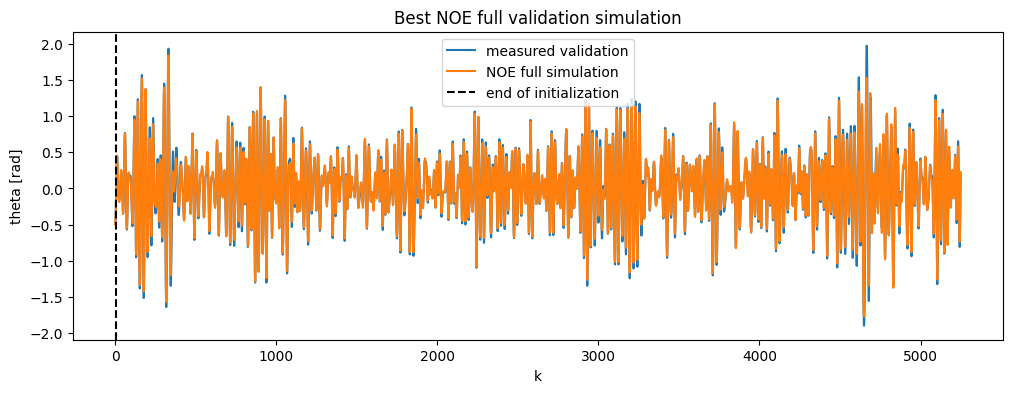

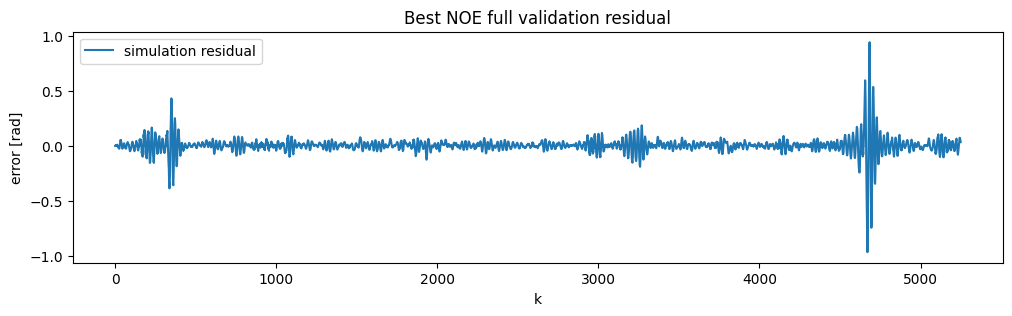

In [46]:
th_val_sim, th_val_true = simulate_noe_full(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
rms_deg = rms / (2*np.pi) * 360
nrms = rms / np.std(th_val_true[skip:])

print("Full validation simulation RMS:", rms, "rad")
print("Full validation simulation RMS:", rms_deg, "deg")
print("Full validation simulation NRMS:", nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim, label="NOE full simulation")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best NOE full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_sim - th_val_true, label="simulation residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best NOE full validation residual")
plt.legend()
plt.show()

In [28]:
best_noe_config = {
    "na": 5,
    "nb": 2,
    "hidden_size": 10,
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "epochs": 150
}

final_noe_model = NOENet(
    na=best_noe_config["na"],
    nb=best_noe_config["nb"],
    hidden_size=best_noe_config["hidden_size"]
)

train_losses, val_losses = train_noe(
    final_noe_model,
    train_loader,
    U_val_t,
    Y_val_t,
    epochs=best_noe_config["epochs"],
    lr=best_noe_config["lr"],
    weight_decay=best_noe_config["weight_decay"]
)

Epoch    0 | train sim loss = 0.831940 | val sim loss = 0.716278
Epoch   10 | train sim loss = 0.014928 | val sim loss = 0.021732
Epoch   20 | train sim loss = 0.005750 | val sim loss = 0.009132
Epoch   30 | train sim loss = 0.004328 | val sim loss = 0.006691
Epoch   40 | train sim loss = 0.003725 | val sim loss = 0.005299
Epoch   50 | train sim loss = 0.003043 | val sim loss = 0.004057
Epoch   60 | train sim loss = 0.002443 | val sim loss = 0.003139
Epoch   70 | train sim loss = 0.002016 | val sim loss = 0.002849
Epoch   80 | train sim loss = 0.001759 | val sim loss = 0.002432
Epoch   90 | train sim loss = 0.001471 | val sim loss = 0.001879
Epoch  100 | train sim loss = 0.001220 | val sim loss = 0.001826
Epoch  110 | train sim loss = 0.000970 | val sim loss = 0.001326
Epoch  120 | train sim loss = 0.000818 | val sim loss = 0.001250
Epoch  130 | train sim loss = 0.000721 | val sim loss = 0.001043
Epoch  140 | train sim loss = 0.000655 | val sim loss = 0.000826


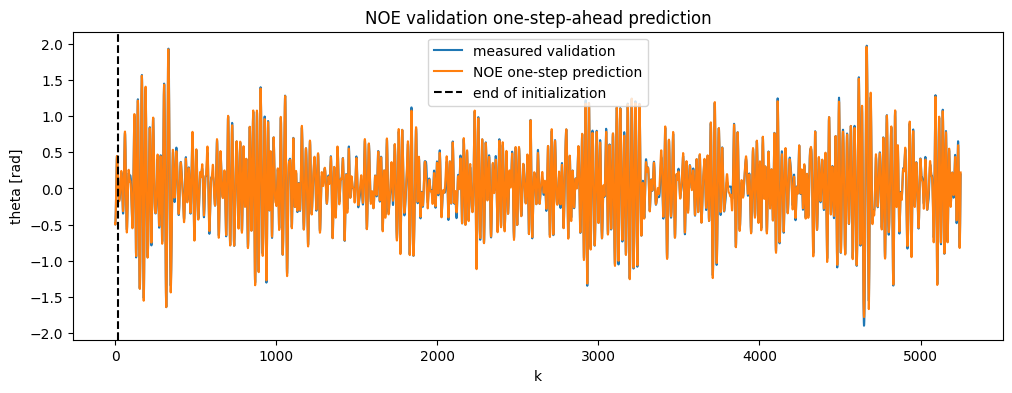

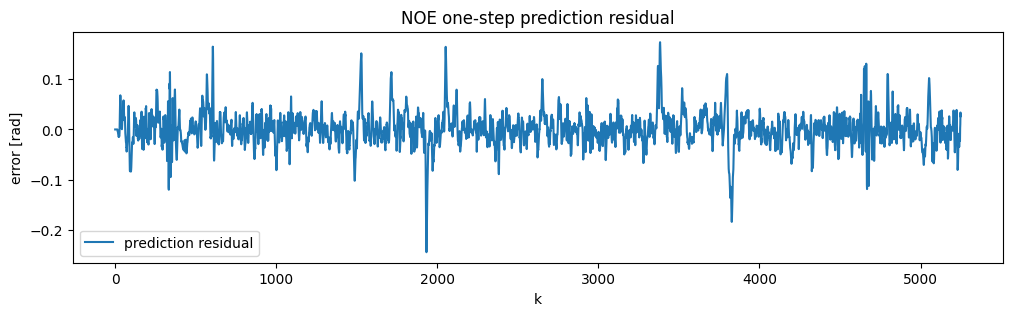

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_pred, label="measured validation")
plt.plot(th_val_pred, label="NOE one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("NOE validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred - th_val_true_pred, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("NOE one-step prediction residual")
plt.legend()
plt.show()

## One-step-ahead prediction evaluation

The final NOE model was also evaluated in one-step-ahead prediction mode. In contrast to free-run simulation, the measured past outputs were used as regressors at every time step. This makes the task easier than simulation, since prediction errors are not recursively fed back into the model. The resulting prediction performance was evaluated using RMSE, RMSE in degrees and NRMS.

The final NOE model was also evaluated in one-step-ahead prediction mode. In this case, measured past outputs were used as regressors at every time step, instead of recursively feeding back the model predictions. This makes one-step prediction easier than free-run simulation, because prediction errors do not accumulate over time and also excuses why have better results than simulation.

The final NOE model achieved a validation one-step prediction RMSE of 0.02495 rad, corresponding to 1.43 degrees and an NRMS of 5.07%. As expected, this is lower than the full simulation RMSE of 0.03088 rad. However, the prediction performance is not as strong as the provided good NN prediction benchmark, since the NOE model was mainly trained using simulation error rather than a pure one-step prediction objective.

# RNN

## RNN sequence data

For the RNN model, the normalized input-output time series was converted into overlapping sequences of length `nfuture_rnn`. This follows the sequence construction used in the lecture exercise. Each training sample contains an input voltage sequence and the corresponding measured angle sequence.

In [20]:
nfuture_rnn = 100

U_train_rnn, Y_train_rnn = make_OE_data(u_train_n, th_train_n, nf=nfuture_rnn)
U_val_rnn, Y_val_rnn = make_OE_data(u_val_n, th_val_n, nf=nfuture_rnn)

U_train_rnn_t = torch.tensor(U_train_rnn, dtype=torch.float64)
Y_train_rnn_t = torch.tensor(Y_train_rnn, dtype=torch.float64)

U_val_rnn_t = torch.tensor(U_val_rnn, dtype=torch.float64)
Y_val_rnn_t = torch.tensor(Y_val_rnn, dtype=torch.float64)

print(U_train_rnn_t.shape, Y_train_rnn_t.shape)
print(U_val_rnn_t.shape, Y_val_rnn_t.shape)

torch.Size([24401, 100]) torch.Size([24401, 100])
torch.Size([5151, 100]) torch.Size([5151, 100])


## Simple RNN model

The RNN model follows the structure used in the lecture exercise. It consists of two neural networks: `h2h`, which updates the hidden state, and `h2o`, which maps the current hidden state and input to the output. The model equations are

h_{k+1} = \text{h2h}(h_k,u_k),

hat{\theta}_k = \text{h2o}(h_k,u_k).

The hidden state is initialized to zero at the start of each sequence.

In [21]:
class simple_RNN(nn.Module):
    def __init__(self, hidden_size):
        super(simple_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.hidden_size + self.input_size, self.hidden_size)
        self.h2o = net(self.hidden_size + self.input_size, self.output_size)

    def forward(self, inputs):
        # inputs shape = (N_batch, N_time)

        N_batch = inputs.shape[0]
        N_time = inputs.shape[1]

        hidden = torch.zeros(
            N_batch,
            self.hidden_size,
            dtype=torch.float64
        )

        outputs = []

        for k in range(N_time):
            uk = inputs[:, k:k+1]

            h_and_u = torch.cat((hidden, uk), dim=1)

            yk = self.h2o(h_and_u)[:, 0]

            hidden = self.h2h(h_and_u)

            outputs.append(yk)

        outputs = torch.stack(outputs, dim=1)

        return outputs

## RNN training

The RNN was trained using mini-batch optimization with the Adam optimizer, following the lecture exercise. The loss was computed after a burn-in period of `n_burn` samples, because the hidden state is initialized at zero and needs a few samples to encode information about the system state. The training and validation losses are reported as normalized sequence RMSE values.

In [12]:
n_burn = 15
batch_size = 64
hidden_size = 15
epochs = 50

model_rnn = simple_RNN(hidden_size=hidden_size)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

train_losses_rnn = []
val_losses_rnn = []

ids = np.arange(len(U_train_rnn_t), dtype=int)

for epoch in range(epochs):
    np.random.shuffle(ids)

    for i in range(0, len(U_train_rnn_t), batch_size):
        ids_now = ids[i:i+batch_size]

        U_batch = U_train_rnn_t[ids_now]
        Y_batch = Y_train_rnn_t[ids_now]

        Y_pred = model_rnn(inputs=U_batch)

        loss = torch.mean((Y_pred[:, n_burn:] - Y_batch[:, n_burn:])**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        train_loss = torch.mean((model_rnn(inputs=U_train_rnn_t)[:, n_burn:] - Y_train_rnn_t[:, n_burn:])**2).sqrt()
        val_loss = torch.mean((model_rnn(inputs=U_val_rnn_t)[:, n_burn:] - Y_val_rnn_t[:, n_burn:])**2).sqrt()

    train_losses_rnn.append(train_loss.item())
    val_losses_rnn.append(val_loss.item())

    print(f"epoch={epoch}, Validation Loss={val_loss.item():.2%}, Train Loss={train_loss.item():.2%}")

epoch=0, Validation Loss=86.29%, Train Loss=81.47%
epoch=1, Validation Loss=54.90%, Train Loss=49.11%
epoch=2, Validation Loss=50.28%, Train Loss=43.60%
epoch=3, Validation Loss=49.43%, Train Loss=42.28%
epoch=4, Validation Loss=51.10%, Train Loss=43.75%
epoch=5, Validation Loss=48.88%, Train Loss=41.64%
epoch=6, Validation Loss=49.08%, Train Loss=41.56%
epoch=7, Validation Loss=48.88%, Train Loss=41.37%
epoch=8, Validation Loss=48.91%, Train Loss=42.06%
epoch=9, Validation Loss=48.70%, Train Loss=41.53%
epoch=10, Validation Loss=49.22%, Train Loss=41.45%
epoch=11, Validation Loss=50.94%, Train Loss=43.67%
epoch=12, Validation Loss=49.97%, Train Loss=42.94%
epoch=13, Validation Loss=48.75%, Train Loss=41.49%
epoch=14, Validation Loss=49.30%, Train Loss=41.54%
epoch=15, Validation Loss=48.17%, Train Loss=41.42%
epoch=16, Validation Loss=48.31%, Train Loss=41.17%
epoch=17, Validation Loss=49.40%, Train Loss=42.41%
epoch=18, Validation Loss=49.34%, Train Loss=41.66%
epoch=19, Validation L

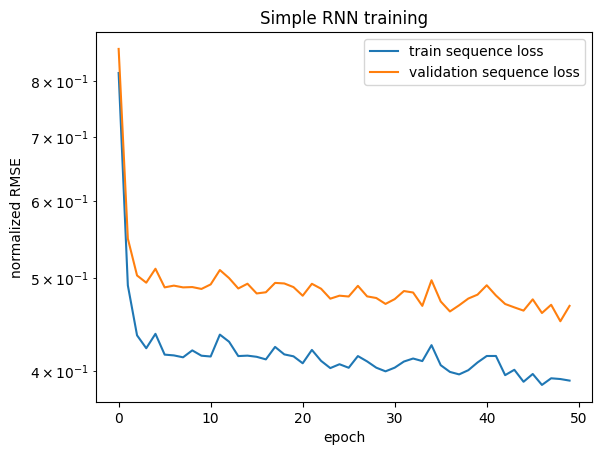

In [13]:
plt.figure()
plt.plot(train_losses_rnn, label="train sequence loss")
plt.plot(val_losses_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Simple RNN training")
plt.legend()
plt.show()

## Full validation simulation with the RNN

The trained RNN was evaluated on the full validation input sequence. The hidden state was initialized to zero and then updated recursively using the input sequence. The first `n_burn` samples were skipped when computing the RMSE, because they correspond to the initial transient of the hidden state. The simulated output was compared with the measured validation angle.

RNN full validation simulation RMS: 0.14364393502652292 rad
RNN full validation simulation RMS: 8.23019122967118 deg
RNN full validation simulation NRMS: 29.167014254304064 %


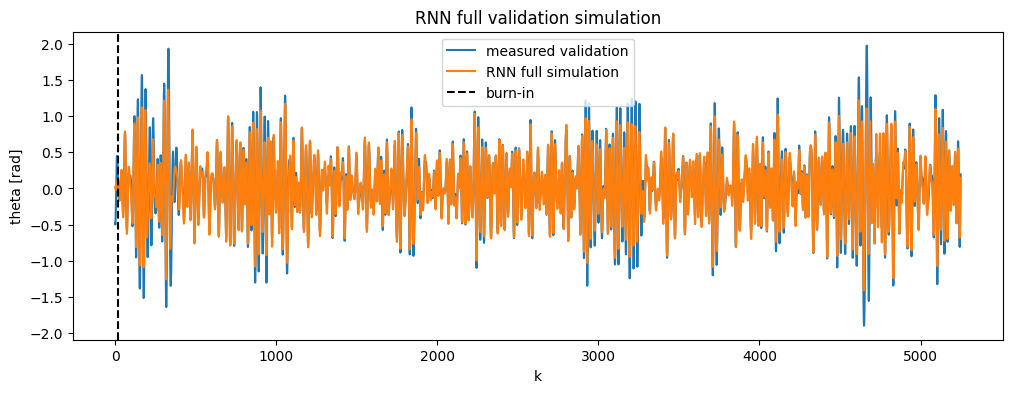

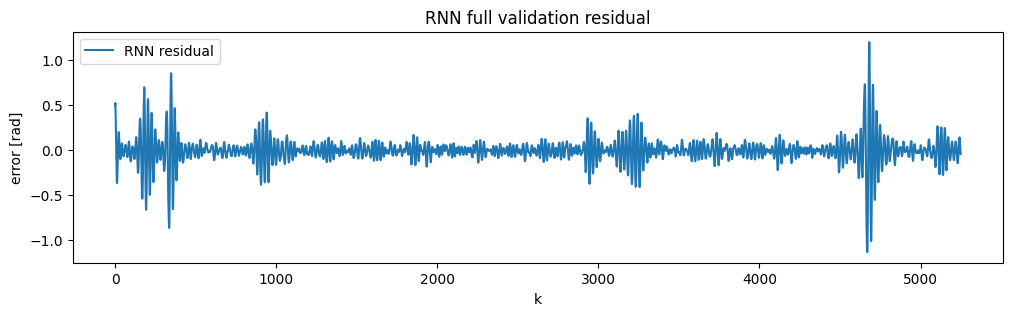

In [14]:
model_rnn.eval()

with torch.no_grad():
    U_val_full_t = torch.tensor(u_val_n[None, :], dtype=torch.float64)
    th_val_sim_rnn_n = model_rnn(U_val_full_t).numpy()[0]

th_val_sim_rnn = th_val_sim_rnn_n * th_std + th_mean
th_val_true = th_val_n * th_std + th_mean

skip = n_burn

rms_rnn = np.sqrt(np.mean((th_val_sim_rnn[skip:] - th_val_true[skip:])**2))
rms_deg_rnn = rms_rnn / (2*np.pi) * 360
nrms_rnn = rms_rnn / np.std(th_val_true[skip:])

print("RNN full validation simulation RMS:", rms_rnn, "rad")
print("RNN full validation simulation RMS:", rms_deg_rnn, "deg")
print("RNN full validation simulation NRMS:", nrms_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim_rnn, label="RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="burn-in")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_rnn - th_val_true, label="RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("RNN full validation residual")
plt.legend()
plt.show()

## Encoder RNN sequence data

For the encoder RNN, each training sample contains three parts: a future input sequence \(U_k\), the corresponding output sequence \(Y_k\), and a history vector containing past inputs and past outputs. The history vector is used by the encoder network to estimate the initial hidden state of the RNN.

In [22]:
def make_OE_init_state_data(udata, ydata, nf=100, n_encode=20):
    U = [] 
    Y = [] 
    hist = [] 

    for k in range(nf + n_encode, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])

        u_past = udata[k-nf-n_encode:k-nf]
        y_past = ydata[k-nf-n_encode:k-nf]

        hist.append(np.concatenate((u_past, y_past)))

    return np.array(hist), np.array(U), np.array(Y)

## Encoder history length

The encoder history length was set to \(n_e=20\). Therefore, the encoder input contains 20 past input samples and 20 past output samples. This provides the RNN with information about the initial state before the simulated sequence starts.

In [23]:
nfuture_rnn = 100
n_encode = 50

convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
    make_OE_init_state_data(
        u_train_n,
        th_train_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
    make_OE_init_state_data(
        u_val_n,
        th_val_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

print("hist_train:", hist_train_rnn.shape)
print("U_train:", U_train_rnn.shape)
print("Y_train:", Y_train_rnn.shape)

print("hist_val:", hist_val_rnn.shape)
print("U_val:", U_val_rnn.shape)
print("Y_val:", Y_val_rnn.shape)

hist_train: torch.Size([24351, 100])
U_train: torch.Size([24351, 100])
Y_train: torch.Size([24351, 100])
hist_val: torch.Size([5101, 100])
U_val: torch.Size([5101, 100])
Y_val: torch.Size([5101, 100])


## Encoder RNN model

In [24]:
class simple_encoder_RNN(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

## Encoder RNN training

The encoder RNN was trained using the Adam optimizer and mean squared sequence error. In contrast to the simple RNN, no burn-in period is required, because the initial hidden state is estimated directly from the past input-output history using the encoder network.

In [38]:
encoder_rnn_configs = [
    {"n_encode": 20, "hidden_size": 15, "epochs": 50, "lr": 1e-3},
    {"n_encode": 50, "hidden_size": 15, "epochs": 50, "lr": 1e-3},
    {"n_encode": 50, "hidden_size": 30, "epochs": 50, "lr": 1e-3},
    {"n_encode": 75, "hidden_size": 30, "epochs": 50, "lr": 1e-3},
]

encoder_rnn_results = []

best_encoder_rmse = np.inf
best_encoder_rnn = None
best_encoder_config = None
best_encoder_losses = None
best_encoder_n_encode = None

nfuture_rnn = 100
batch_size = 64

for cfg in encoder_rnn_configs:
    print("\n====================================")
    print("Training Encoder RNN config:", cfg)
    print("====================================")

    n_encode = cfg["n_encode"]
    hidden_size = cfg["hidden_size"]
    epochs = cfg["epochs"]
    lr = cfg["lr"]

    # Recreate data for this encoder length
    convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

    hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
        make_OE_init_state_data(
            u_train_n,
            th_train_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
        make_OE_init_state_data(
            u_val_n,
            th_val_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    model_encoder_rnn = simple_encoder_RNN(
        hidden_size=hidden_size,
        n_encoder=n_encode
    )

    optimizer = torch.optim.Adam(model_encoder_rnn.parameters(), lr=lr)

    train_losses_encoder_rnn = []
    val_losses_encoder_rnn = []

    ids = np.arange(len(U_train_rnn), dtype=int)

    for epoch in range(epochs):
        np.random.shuffle(ids)

        model_encoder_rnn.train()

        for i in range(0, len(U_train_rnn), batch_size):
            ids_now = ids[i:i+batch_size]

            Uin = U_train_rnn[ids_now]
            histin = hist_train_rnn[ids_now]
            Y_real = Y_train_rnn[ids_now]

            Y_predict = model_encoder_rnn(inputs=Uin, hist=histin)

            residual = Y_real - Y_predict
            loss = torch.mean(residual**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model_encoder_rnn.eval()
        with torch.no_grad():
            Y_val_pred = model_encoder_rnn(inputs=U_val_rnn, hist=hist_val_rnn)
            Y_train_pred = model_encoder_rnn(inputs=U_train_rnn, hist=hist_train_rnn)

            loss_val = torch.mean((Y_val_pred - Y_val_rnn)**2)**0.5
            loss_train = torch.mean((Y_train_pred - Y_train_rnn)**2)**0.5

        train_losses_encoder_rnn.append(loss_train.item())
        val_losses_encoder_rnn.append(loss_val.item())

        print(f"epoch={epoch}, Validation Loss={loss_val.item():.2%}, Train Loss={loss_train.item():.2%}")

    # Full validation simulation for this config
    th_val_sim_encoder_rnn, th_val_true_encoder_rnn = simulate_encoder_rnn_full(
        model_encoder_rnn,
        u_val_n,
        th_val_n,
        n_encode,
        th_mean,
        th_std
    )

    skip = n_encode

    rms_encoder_rnn = np.sqrt(
        np.mean((th_val_sim_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
    )
    rms_deg_encoder_rnn = rms_encoder_rnn / (2*np.pi) * 360
    nrms_encoder_rnn = rms_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

    print("Encoder RNN full validation simulation RMS:", rms_encoder_rnn, "rad")
    print("Encoder RNN full validation simulation RMS:", rms_deg_encoder_rnn, "deg")
    print("Encoder RNN full validation simulation NRMS:", nrms_encoder_rnn * 100, "%")

    result = {
        "n_encode": n_encode,
        "hidden_size": hidden_size,
        "epochs": epochs,
        "lr": lr,
        "rmse_rad": rms_encoder_rnn,
        "rmse_deg": rms_deg_encoder_rnn,
        "nrms_percent": nrms_encoder_rnn * 100,
        "best_window_val_loss": np.min(val_losses_encoder_rnn),
        "best_epoch": int(np.argmin(val_losses_encoder_rnn))
    }

    encoder_rnn_results.append(result)

    if rms_encoder_rnn < best_encoder_rmse:
        best_encoder_rmse = rms_encoder_rnn
        best_encoder_rnn = copy.deepcopy(model_encoder_rnn)
        best_encoder_config = copy.deepcopy(cfg)
        best_encoder_losses = (train_losses_encoder_rnn, val_losses_encoder_rnn)
        best_encoder_n_encode = n_encode
        best_encoder_sim = th_val_sim_encoder_rnn
        best_encoder_true = th_val_true_encoder_rnn

encoder_rnn_results_df = pd.DataFrame(encoder_rnn_results)
encoder_rnn_results_df.sort_values("rmse_rad")


Training Encoder RNN config: {'n_encode': 20, 'hidden_size': 15, 'epochs': 50, 'lr': 0.001}
epoch=0, Validation Loss=83.97%, Train Loss=79.11%
epoch=1, Validation Loss=42.35%, Train Loss=36.25%
epoch=2, Validation Loss=36.21%, Train Loss=28.43%
epoch=3, Validation Loss=35.27%, Train Loss=28.90%
epoch=4, Validation Loss=35.18%, Train Loss=29.03%
epoch=5, Validation Loss=33.66%, Train Loss=26.12%
epoch=6, Validation Loss=32.77%, Train Loss=25.90%
epoch=7, Validation Loss=33.35%, Train Loss=26.07%
epoch=8, Validation Loss=33.32%, Train Loss=26.32%
epoch=9, Validation Loss=30.45%, Train Loss=23.96%
epoch=10, Validation Loss=30.99%, Train Loss=23.95%
epoch=11, Validation Loss=32.22%, Train Loss=27.89%
epoch=12, Validation Loss=30.11%, Train Loss=23.37%
epoch=13, Validation Loss=27.72%, Train Loss=22.27%
epoch=14, Validation Loss=28.03%, Train Loss=22.49%
epoch=15, Validation Loss=27.00%, Train Loss=21.39%
epoch=16, Validation Loss=26.01%, Train Loss=20.42%
epoch=17, Validation Loss=25.76%,

,n_encode,hidden_size,epochs,lr,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,20,15,50,0.001,0.067172,3.848698,13.633699,0.126173,49
3,75,30,50,0.001,0.072617,4.160658,14.698427,0.136597,45
1,50,15,50,0.001,0.079238,4.539986,16.042381,0.137282,47
2,50,30,50,0.001,0.090373,5.178017,18.296912,0.141876,38


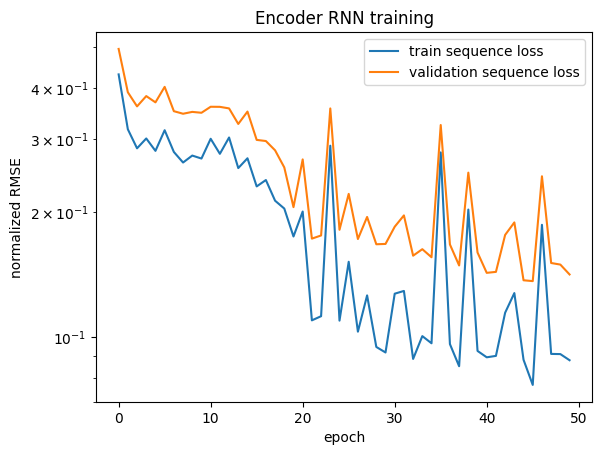

In [39]:
plt.figure()
plt.plot(train_losses_encoder_rnn, label="train sequence loss")
plt.plot(val_losses_encoder_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Encoder RNN training")
plt.legend()
plt.show()

### Full validation simulation with encoder RNN

For the full validation simulation, the first \(n_e\) measured input-output samples were used as encoder history to estimate the initial hidden state. After this initialization, the RNN simulated the remaining validation sequence using only the input signal and the recurrent hidden state dynamics.

In [40]:
def simulate_encoder_rnn_full(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    Full validation simulation for encoder RNN.

    Uses the first n_encode input-output samples as history to initialize hidden state.
    Then simulates the rest of the sequence.
    """

    model.eval()

    u_hist = u_seq[:n_encode]
    y_hist = y_seq[:n_encode]

    hist = np.concatenate((u_hist, y_hist))[None, :]
    u_future = u_seq[n_encode:][None, :]

    hist_t = torch.tensor(hist, dtype=torch.float64)
    u_future_t = torch.tensor(u_future, dtype=torch.float64)

    with torch.no_grad():
        y_future_pred_n = model(inputs=u_future_t, hist=hist_t).numpy()[0]

    y_pred_n = np.concatenate((y_seq[:n_encode], y_future_pred_n))

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

Encoder RNN full validation simulation RMS: 0.07261718945692414 rad
Encoder RNN full validation simulation RMS: 4.160658475983651 deg
Encoder RNN full validation simulation NRMS: 14.698427309290002 %


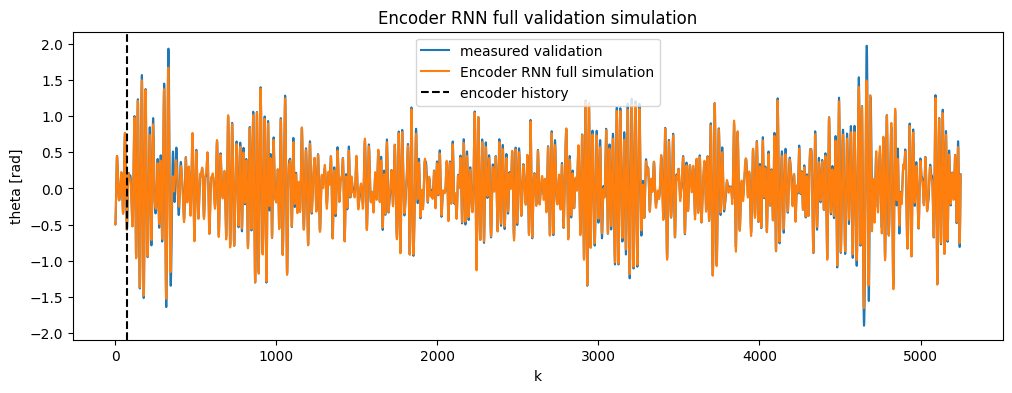

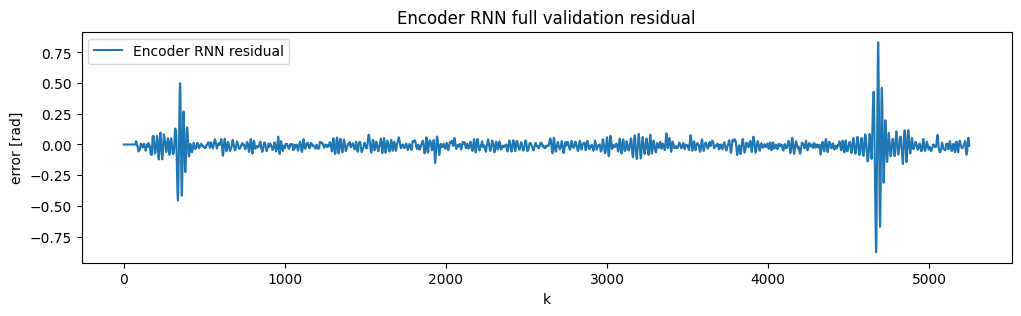

In [41]:
th_val_sim_encoder_rnn, th_val_true_encoder_rnn = simulate_encoder_rnn_full(
    model_encoder_rnn,
    u_val_n,
    th_val_n,
    n_encode,
    th_mean,
    th_std
)

skip = n_encode

rms_encoder_rnn = np.sqrt(
    np.mean((th_val_sim_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_encoder_rnn = rms_encoder_rnn / (2*np.pi) * 360
nrms_encoder_rnn = rms_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN full validation simulation RMS:", rms_encoder_rnn, "rad")
print("Encoder RNN full validation simulation RMS:", rms_deg_encoder_rnn, "deg")
print("Encoder RNN full validation simulation NRMS:", nrms_encoder_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_sim_encoder_rnn, label="Encoder RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_encoder_rnn - th_val_true_encoder_rnn, label="Encoder RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN full validation residual")
plt.legend()
plt.show()

## RNN tuning summary

As a recurrent neural-network baseline, a simple RNN was first trained using the structure from the exercise set. In this model, the hidden state was initialized to zero at the beginning of each sequence. The simple RNN achieved a full validation simulation RMSE of 0.1436 rad. This was better than the linear benchmark, but still significantly worse than the NOE model. The main limitation is that the zero initial hidden state does not contain information about the actual initial state of the system.

To improve this, an encoder RNN was tested. In this architecture, the initial hidden state is not fixed to zero, but is estimated from a past input-output history:


h_0 = encoder(u_{\text{past}}, y_{\text{past}})


This improved the full validation simulation RMSE from 0.1436 rad to 0.0909 rad for \(n_{encode}=20\) and hidden size 15. This confirmed that estimating the initial hidden state from past data is important for recurrent models in system identification.

The encoder history length and hidden state dimension were then tuned. Increasing the encoder history from \(n_{encode}=20\) to \(n_{encode}=50\) improved the result further, because the encoder had more information about the recent system behavior. With \(n_{encode}=50\) and hidden size 15, the RMSE decreased to 0.0835 rad. Increasing the hidden size to 30 with the same encoder history gave the best RNN result, with RMSE 0.0772 rad, corresponding to 4.42 degrees and NRMS 15.63%.

Additional experiments showed that further increasing the number of epochs from 50 to 100 did not improve the full validation simulation performance. Although the training loss continued to decrease, the full validation RMSE increased to 0.1039 rad, indicating overfitting or unstable long-horizon recurrent behavior. A larger encoder history of \(n_{encode}=100\) also worsened the performance, giving RMSE 0.2045 rad. This suggests that too large an encoder input dimension can make the initial state estimation problem harder for this relatively simple encoder network.

Overall, the encoder RNN clearly improved over the simple RNN, showing that hidden-state initialization is important. However, the best RNN result remained worse than the final NOE model. This indicates that, for this dataset and this simple RNN architecture, the explicit delayed-output structure of the NOE model was more effective than the learned hidden-state representation of the RNN.

## Encoder RNN one-step-ahead prediction

The best encoder RNN model was also evaluated in one-step-ahead prediction mode. For each validation time step, the encoder used the measured past input-output history to estimate the initial hidden state, and the RNN then predicted only the next output sample. This is easier than full free-run simulation, because the model is re-initialized from measured past data at every time step and prediction errors do not accumulate over the full validation trajectory.

In [42]:
final_encoder_rnn = model_encoder_rnn   
final_n_encode = 50                     

In [43]:
def one_step_prediction_encoder_rnn(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    One-step-ahead prediction for the encoder RNN.

    At each time step, the encoder uses measured past input-output data
    to initialize the hidden state, and then predicts only the next output.
    """

    model.eval()

    y_pred_n = []

    # Copy first n_encode samples only to keep the same signal length
    for i in range(n_encode):
        y_pred_n.append(y_seq[i])

    with torch.no_grad():
        for k in range(n_encode, len(u_seq)):
            u_hist = u_seq[k-n_encode:k]
            y_hist = y_seq[k-n_encode:k]

            hist = np.concatenate((u_hist, y_hist))[None, :]
            u_now = u_seq[k:k+1][None, :]

            hist_t = torch.tensor(hist, dtype=torch.float64)
            u_now_t = torch.tensor(u_now, dtype=torch.float64)

            y_now_pred = model(inputs=u_now_t, hist=hist_t).numpy()[0, 0]

            y_pred_n.append(y_now_pred)

    y_pred_n = np.array(y_pred_n)

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

In [45]:
final_n_encode = final_encoder_rnn.n_encoder

th_val_pred_encoder_rnn, th_val_true_encoder_rnn = one_step_prediction_encoder_rnn(
    final_encoder_rnn,
    u_val_n,
    th_val_n,
    final_n_encode,
    th_mean,
    th_std
)

skip = final_n_encode

rms_pred_encoder_rnn = np.sqrt(
    np.mean((th_val_pred_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_pred_encoder_rnn = rms_pred_encoder_rnn / (2*np.pi) * 360
nrms_pred_encoder_rnn = rms_pred_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN one-step prediction RMS:", rms_pred_encoder_rnn, "rad")
print("Encoder RNN one-step prediction RMS:", rms_deg_pred_encoder_rnn, "deg")
print("Encoder RNN one-step prediction NRMS:", nrms_pred_encoder_rnn * 100, "%")

Encoder RNN one-step prediction RMS: 0.050933706779025714 rad
Encoder RNN one-step prediction RMS: 2.9182864333950436 deg
Encoder RNN one-step prediction NRMS: 10.309478957847722 %


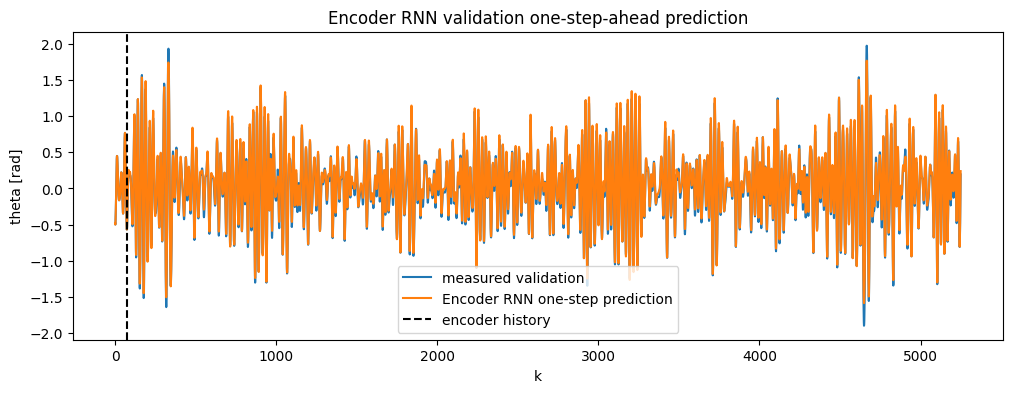

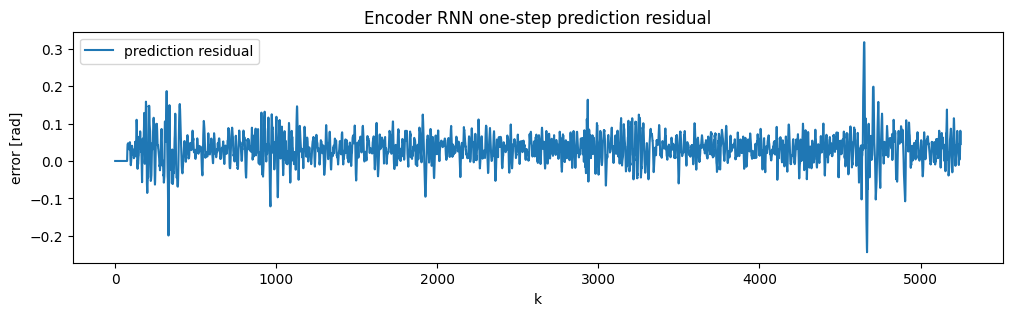

In [46]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_pred_encoder_rnn, label="Encoder RNN one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred_encoder_rnn - th_val_true_encoder_rnn, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN one-step prediction residual")
plt.legend()
plt.show()

# Try with tanH

In [26]:
class simple_encoder_RNN_tanh(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN_tanh, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Tanh(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

In [31]:
tanh_rnn_configs = [
    {"n_encode": 50, "hidden_size": 30, "epochs": 50, "lr": 1e-3}
]

tanh_rnn_results = []

best_tanh_rmse = np.inf
best_tanh_rnn = None
best_tanh_config = None
best_tanh_losses = None
best_tanh_n_encode = None
best_tanh_sim = None
best_tanh_true = None

nfuture_rnn = 100
batch_size = 64

for cfg in tanh_rnn_configs:
    print("\n====================================")
    print("Training Tanh Encoder RNN config:", cfg)
    print("====================================")

    n_encode = cfg["n_encode"]
    hidden_size = cfg["hidden_size"]
    epochs = cfg["epochs"]
    lr = cfg["lr"]

    convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

    hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
        make_OE_init_state_data(
            u_train_n,
            th_train_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
        make_OE_init_state_data(
            u_val_n,
            th_val_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    model_tanh_rnn = simple_encoder_RNN_tanh(
        hidden_size=hidden_size,
        n_encoder=n_encode
    )

    optimizer = torch.optim.Adam(model_tanh_rnn.parameters(), lr=lr)

    train_losses_tanh = []
    val_losses_tanh = []

    ids = np.arange(len(U_train_rnn), dtype=int)

    for epoch in range(epochs):
        np.random.shuffle(ids)

        model_tanh_rnn.train()

        for i in range(0, len(U_train_rnn), batch_size):
            ids_now = ids[i:i+batch_size]

            Uin = U_train_rnn[ids_now]
            histin = hist_train_rnn[ids_now]
            Y_real = Y_train_rnn[ids_now]

            Y_predict = model_tanh_rnn(inputs=Uin, hist=histin)

            loss = torch.mean((Y_real - Y_predict)**2)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping for recurrent training stability
            torch.nn.utils.clip_grad_norm_(model_tanh_rnn.parameters(), max_norm=1.0)

            optimizer.step()

        model_tanh_rnn.eval()
        with torch.no_grad():
            Y_val_pred = model_tanh_rnn(inputs=U_val_rnn, hist=hist_val_rnn)
            Y_train_pred = model_tanh_rnn(inputs=U_train_rnn, hist=hist_train_rnn)

            loss_val = torch.mean((Y_val_pred - Y_val_rnn)**2)**0.5
            loss_train = torch.mean((Y_train_pred - Y_train_rnn)**2)**0.5

        train_losses_tanh.append(loss_train.item())
        val_losses_tanh.append(loss_val.item())

        print(f"epoch={epoch}, Validation Loss={loss_val.item():.2%}, Train Loss={loss_train.item():.2%}")

    th_val_sim_tanh, th_val_true_tanh = simulate_encoder_rnn_full(
        model_tanh_rnn,
        u_val_n,
        th_val_n,
        n_encode,
        th_mean,
        th_std
    )

    skip = n_encode

    rms_tanh = np.sqrt(
        np.mean((th_val_sim_tanh[skip:] - th_val_true_tanh[skip:])**2)
    )
    rms_deg_tanh = rms_tanh / (2*np.pi) * 360
    nrms_tanh = rms_tanh / np.std(th_val_true_tanh[skip:])

    print("Tanh Encoder RNN full validation simulation RMS:", rms_tanh, "rad")
    print("Tanh Encoder RNN full validation simulation RMS:", rms_deg_tanh, "deg")
    print("Tanh Encoder RNN full validation simulation NRMS:", nrms_tanh * 100, "%")

    result = {
        "activation": "tanh",
        "n_encode": n_encode,
        "hidden_size": hidden_size,
        "epochs": epochs,
        "lr": lr,
        "rmse_rad": rms_tanh,
        "rmse_deg": rms_deg_tanh,
        "nrms_percent": nrms_tanh * 100,
        "best_window_val_loss": np.min(val_losses_tanh),
        "best_epoch": int(np.argmin(val_losses_tanh))
    }

    tanh_rnn_results.append(result)

    if rms_tanh < best_tanh_rmse:
        best_tanh_rmse = rms_tanh
        best_tanh_rnn = copy.deepcopy(model_tanh_rnn)
        best_tanh_config = copy.deepcopy(cfg)
        best_tanh_losses = (train_losses_tanh, val_losses_tanh)
        best_tanh_n_encode = n_encode
        best_tanh_sim = th_val_sim_tanh
        best_tanh_true = th_val_true_tanh

tanh_rnn_results_df = pd.DataFrame(tanh_rnn_results)
tanh_rnn_results_df.sort_values("rmse_rad")


Training Tanh Encoder RNN config: {'n_encode': 50, 'hidden_size': 30, 'epochs': 50, 'lr': 0.001}
epoch=0, Validation Loss=38.18%, Train Loss=30.29%
epoch=1, Validation Loss=37.37%, Train Loss=29.16%
epoch=2, Validation Loss=35.83%, Train Loss=29.09%
epoch=3, Validation Loss=30.67%, Train Loss=24.74%
epoch=4, Validation Loss=24.87%, Train Loss=16.81%
epoch=5, Validation Loss=20.02%, Train Loss=11.43%
epoch=6, Validation Loss=37.39%, Train Loss=33.44%
epoch=7, Validation Loss=22.00%, Train Loss=14.69%
epoch=8, Validation Loss=19.45%, Train Loss=13.01%
epoch=9, Validation Loss=24.36%, Train Loss=17.21%
epoch=10, Validation Loss=20.65%, Train Loss=13.21%
epoch=11, Validation Loss=22.59%, Train Loss=18.46%
epoch=12, Validation Loss=31.55%, Train Loss=26.47%
epoch=13, Validation Loss=20.20%, Train Loss=14.46%
epoch=14, Validation Loss=21.93%, Train Loss=16.39%
epoch=15, Validation Loss=23.93%, Train Loss=17.06%
epoch=16, Validation Loss=26.80%, Train Loss=21.93%
epoch=17, Validation Loss=20

,activation,n_encode,hidden_size,epochs,lr,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,tanh,50,30,50,0.001,0.157087,9.000425,31.803676,0.13975,45


In [32]:
print("Best Tanh Encoder RNN configuration:")
print(best_tanh_config)

print("\nBest Tanh Encoder RNN full validation RMSE:", best_tanh_rmse, "rad")

tanh_rnn_results_df.sort_values("rmse_rad")

Best Tanh Encoder RNN configuration:
{'n_encode': 50, 'hidden_size': 30, 'epochs': 50, 'lr': 0.001}

Best Tanh Encoder RNN full validation RMSE: 0.15708705423740071 rad


,activation,n_encode,hidden_size,epochs,lr,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,tanh,50,30,50,0.001,0.157087,9.000425,31.803676,0.13975,45


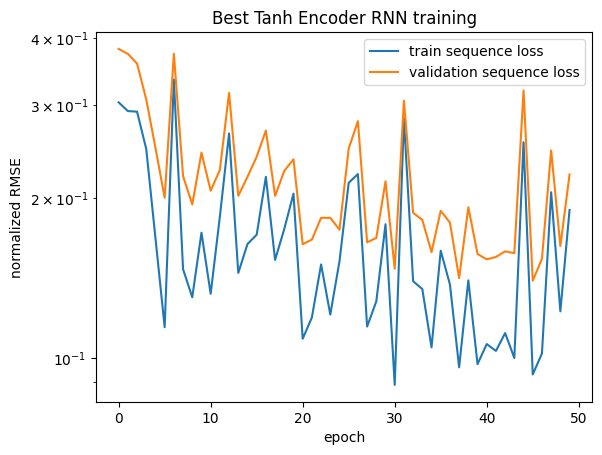

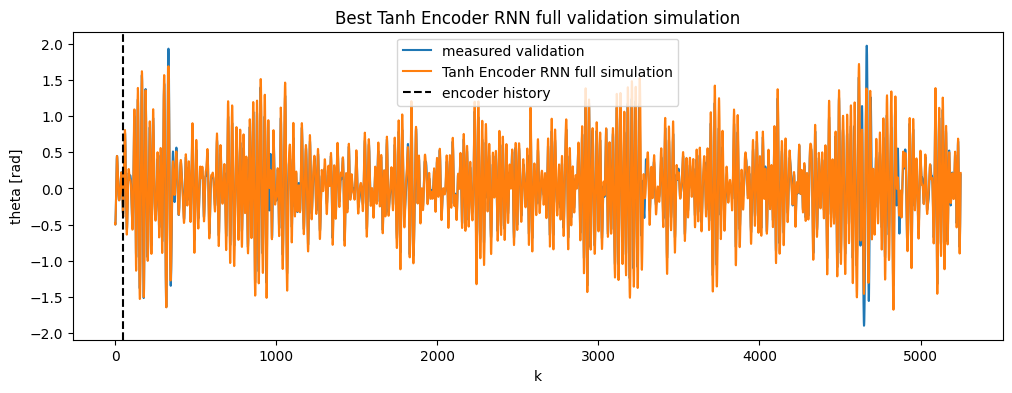

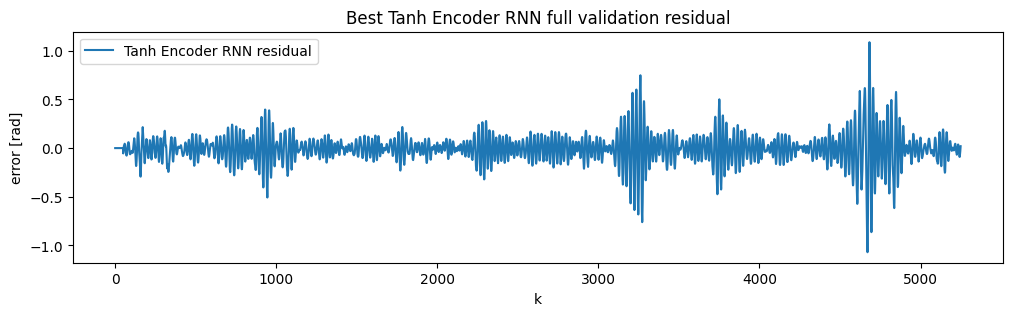

In [34]:
train_losses_tanh, val_losses_tanh = best_tanh_losses

plt.figure()
plt.plot(train_losses_tanh, label="train sequence loss")
plt.plot(val_losses_tanh, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Best Tanh Encoder RNN training")
plt.legend()
plt.show()

skip = best_tanh_n_encode

plt.figure(figsize=(12, 4))
plt.plot(best_tanh_true, label="measured validation")
plt.plot(best_tanh_sim, label="Tanh Encoder RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best Tanh Encoder RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(best_tanh_sim - best_tanh_true, label="Tanh Encoder RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best Tanh Encoder RNN full validation residual")
plt.legend()
plt.show()

In [36]:
final_tanh_rnn = best_tanh_rnn
final_tanh_n_encode = best_tanh_n_encode

th_val_pred_tanh_rnn, th_val_true_tanh_rnn = one_step_prediction_encoder_rnn(
    final_tanh_rnn,
    u_val_n,
    th_val_n,
    final_tanh_n_encode,
    th_mean,
    th_std
)

skip = final_tanh_n_encode

rms_pred_tanh_rnn = np.sqrt(
    np.mean((th_val_pred_tanh_rnn[skip:] - th_val_true_tanh_rnn[skip:])**2)
)

rms_deg_pred_tanh_rnn = rms_pred_tanh_rnn / (2*np.pi) * 360
nrms_pred_tanh_rnn = rms_pred_tanh_rnn / np.std(th_val_true_tanh_rnn[skip:])

print("Tanh Encoder RNN one-step prediction RMS:", rms_pred_tanh_rnn, "rad")
print("Tanh Encoder RNN one-step prediction RMS:", rms_deg_pred_tanh_rnn, "deg")
print("Tanh Encoder RNN one-step prediction NRMS:", nrms_pred_tanh_rnn * 100, "%")

Tanh Encoder RNN one-step prediction RMS: 0.07410309299150744 rad
Tanh Encoder RNN one-step prediction RMS: 4.245794477278847 deg
Tanh Encoder RNN one-step prediction NRMS: 15.002832332092975 %


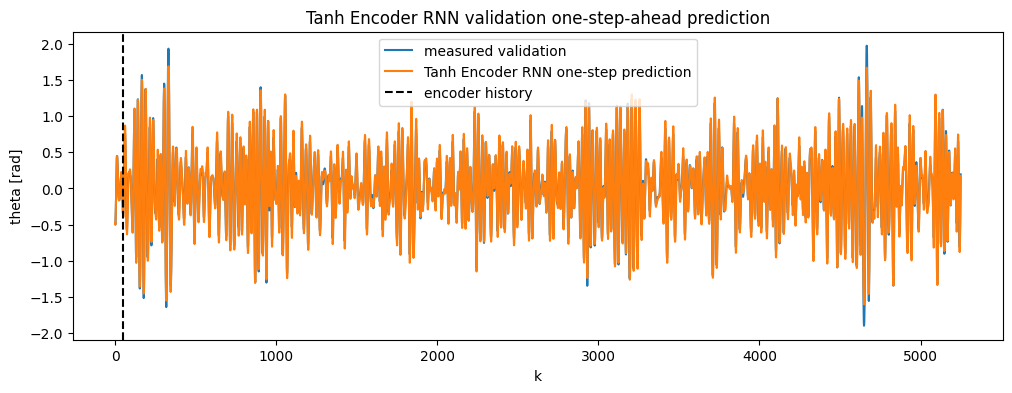

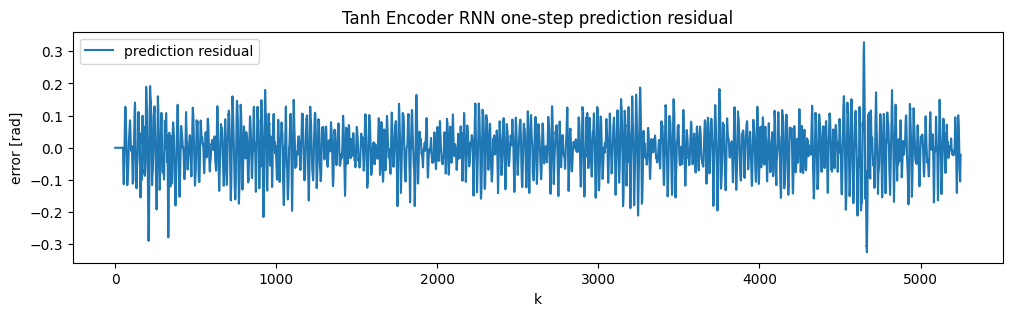

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_tanh_rnn, label="measured validation")
plt.plot(th_val_pred_tanh_rnn, label="Tanh Encoder RNN one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Tanh Encoder RNN validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred_tanh_rnn - th_val_true_tanh_rnn, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Tanh Encoder RNN one-step prediction residual")
plt.legend()
plt.show()